# 🎬 Film Industry EDA — Investment & Strategy Insights
**Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn  
**Dataset:** TMDB Movies Dataset — Kaggle (4,803 films)  
**Business Context:** Analysis conducted from the perspective of a film investment 
consultancy advising studios and producers on budget allocation and strategy.  
**Clean Dataset:** 4,767 films | 24 columns | 3,226 films with complete financial data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid") 

In [2]:
!kaggle datasets download -d utkarshx27/movies-dataset
import zipfile

with zipfile.ZipFile("movies-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("movies_data")

Dataset URL: https://www.kaggle.com/datasets/utkarshx27/movies-dataset
License(s): CC0-1.0
movies-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import os
os.chdir()
print (os.getcwd())
movie = pd.read_csv("movie_dataset.csv")

In [4]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

In [5]:
movie.head(5)

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [6]:
movie.describe()

,index,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4803.000000,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2401.000000,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,1386.651002,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1200.500000,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,2401.000000,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,3601.500000,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,4802.000000,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [7]:
movie.shape

(4803, 24)

In [8]:
movie.dtypes

index                     int64
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
director                 object
dtype: object

In [9]:
movie.describe(include="all")

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
count,4803.000000,4.803000e+03,4775,1712,4803.000000,4391,4803,4803,4800,4803.000000,...,4801.000000,4803,4803,3959,4803,4803.000000,4803.000000,4760,4803,4773
unique,NaN,NaN,1168,1691,NaN,4219,37,4801,4800,NaN,...,NaN,544,3,3944,4800,NaN,NaN,4741,4776,2349
top,NaN,NaN,Drama,http://www.thehungergames.movie/,NaN,independent film,en,Batman,"'Breaking Upwards' explores a young, real-life...",NaN,...,NaN,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Based on a true story.,The Host,NaN,NaN,William Shatner Leonard Nimoy DeForest Kelley ...,[],Steven Spielberg
freq,NaN,NaN,370,4,NaN,55,4505,2,1,NaN,...,NaN,3171,4795,3,2,NaN,NaN,6,28,27
mean,2401.000000,2.904504e+07,NaN,NaN,57165.484281,NaN,NaN,NaN,NaN,21.492301,...,106.875859,NaN,NaN,NaN,NaN,6.092172,690.217989,NaN,NaN,NaN
std,1386.651002,4.072239e+07,NaN,NaN,88694.614033,NaN,NaN,NaN,NaN,31.816650,...,22.611935,NaN,NaN,NaN,NaN,1.194612,1234.585891,NaN,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,0.000000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,1200.500000,7.900000e+05,NaN,NaN,9014.500000,NaN,NaN,NaN,NaN,4.668070,...,94.000000,NaN,NaN,NaN,NaN,5.600000,54.000000,NaN,NaN,NaN
50%,2401.000000,1.500000e+07,NaN,NaN,14629.000000,NaN,NaN,NaN,NaN,12.921594,...,103.000000,NaN,NaN,NaN,NaN,6.200000,235.000000,NaN,NaN,NaN
75%,3601.500000,4.000000e+07,NaN,NaN,58610.500000,NaN,NaN,NaN,NaN,28.313505,...,118.000000,NaN,NaN,NaN,NaN,6.800000,737.000000,NaN,NaN,NaN


In [10]:
movie.isna().sum()

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64

In [11]:
movie.duplicated().sum()

np.int64(0)

In [12]:
movie.columns

Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='object')

In [13]:
movie.columns = (
    movie.columns
    .str.strip()
    .str.capitalize()
    .str.replace(r"\s+"," ", regex = True)
    .str.replace(r"[^\w\s]", "_", regex = True)
    .str.replace(r"[_\s]+","_", regex = True)
)

In [14]:
movie.columns

Index(['Index', 'Budget', 'Genres', 'Homepage', 'Id', 'Keywords',
       'Original_language', 'Original_title', 'Overview', 'Popularity',
       'Production_companies', 'Production_countries', 'Release_date',
       'Revenue', 'Runtime', 'Spoken_languages', 'Status', 'Tagline', 'Title',
       'Vote_average', 'Vote_count', 'Cast', 'Crew', 'Director'],
      dtype='object')

In [15]:
movie.isna().sum()

Index                      0
Budget                     0
Genres                    28
Homepage                3091
Id                         0
Keywords                 412
Original_language          0
Original_title             0
Overview                   3
Popularity                 0
Production_companies       0
Production_countries       0
Release_date               1
Revenue                    0
Runtime                    2
Spoken_languages           0
Status                     0
Tagline                  844
Title                      0
Vote_average               0
Vote_count                 0
Cast                      43
Crew                       0
Director                  30
dtype: int64

In [16]:
mask = pd.to_numeric(movie['Index'], errors='coerce').isna()
invalid_rows = movie[mask]

print(invalid_rows)

Empty DataFrame
Columns: [Index, Budget, Genres, Homepage, Id, Keywords, Original_language, Original_title, Overview, Popularity, Production_companies, Production_countries, Release_date, Revenue, Runtime, Spoken_languages, Status, Tagline, Title, Vote_average, Vote_count, Cast, Crew, Director]
Index: []

[0 rows x 24 columns]


In [17]:
movie = movie.drop(['Homepage', 'Keywords', 'Overview', 'Production_countries', 'Spoken_languages', 'Tagline', 'Crew'] ,axis=1)

In [18]:
movie['Budget'] = movie['Budget'].replace(0, np.nan)
movie['Revenue'] = movie['Revenue'].replace(0, np.nan)

In [19]:
movie['Financial_data_available'] = movie['Budget'].notna() & movie['Revenue'].notna()

In [20]:
print(f"Rows with complete financial data: {movie['Financial_data_available'].sum()} out of {len(movie)}")

Rows with complete financial data: 3229 out of 4803


In [21]:
# Drop rows where vote_average is null
# A film with no rating at all is useless for any analysis
before = movie.shape[0]
movie = movie.dropna(subset=['Vote_average']).copy()
print(f"Dropped {before - movie.shape[0]} zero-rating rows | Remaining: {movie.shape[0]}")

Dropped 0 zero-rating rows | Remaining: 4803


In [22]:
print(movie['Vote_count'].describe())
print("\nFilms with fewer than 10 votes:", (movie['Vote_count'] < 10).sum())
print("Films with fewer than 25 votes:", (movie['Vote_count'] < 25).sum())
print("Films with fewer than 50 votes:", (movie['Vote_count'] < 50).sum())
print("Films with fewer than 100 votes:", (movie['Vote_count'] < 100).sum())

count     4803.000000
mean       690.217989
std       1234.585891
min          0.000000
25%         54.000000
50%        235.000000
75%        737.000000
max      13752.000000
Name: Vote_count, dtype: float64

Films with fewer than 10 votes: 411
Films with fewer than 25 votes: 761
Films with fewer than 50 votes: 1151
Films with fewer than 100 votes: 1641


In [23]:
C = movie['Vote_average'].mean()
m = movie['Vote_count'].quantile(0.25)  # = 54, data-driven threshold

movie['Weighted_rating'] = (
    (movie['Vote_count'] / (movie['Vote_count'] + m)) * movie['Vote_average'] +
    (m / (movie['Vote_count'] + m)) * C
).round(2)

In [24]:
movie['Release_date'] = pd.to_datetime(movie['Release_date'], errors= 'coerce')

In [25]:
print("Release_date dtype:", movie['Release_date'].dtype)

Release_date dtype: datetime64[ns]


In [26]:
movie['Year'] = movie['Release_date'].dt.year
movie['Month'] = movie['Release_date'].dt.month

In [27]:
movie['Year'] = movie['Year'].astype('Int64')
movie['Month'] = movie['Month']. astype('Int64')

In [28]:
movie.dtypes

Index                                int64
Budget                             float64
Genres                              object
Id                                   int64
Original_language                   object
Original_title                      object
Popularity                         float64
Production_companies                object
Release_date                datetime64[ns]
Revenue                            float64
Runtime                            float64
Status                              object
Title                               object
Vote_average                       float64
Vote_count                           int64
Cast                                object
Director                            object
Financial_data_available              bool
Weighted_rating                    float64
Year                                 Int64
Month                                Int64
dtype: object

In [29]:
movie.isna().sum()

Index                          0
Budget                      1037
Genres                        28
Id                             0
Original_language              0
Original_title                 0
Popularity                     0
Production_companies           0
Release_date                   1
Revenue                     1427
Runtime                        2
Status                         0
Title                          0
Vote_average                   0
Vote_count                     0
Cast                          43
Director                      30
Financial_data_available       0
Weighted_rating                0
Year                           1
Month                          1
dtype: int64

In [30]:
print(movie[['Release_date', 'Year', 'Month']].head())

  Release_date  Year  Month
0   2009-12-10  2009     12
1   2007-05-19  2007      5
2   2015-10-26  2015     10
3   2012-07-16  2012      7
4   2012-03-07  2012      3


In [31]:
print("Nulls in Release_date:", movie['Release_date'].isna().sum())

Nulls in Release_date: 1


In [32]:
movie = movie.drop(movie.index[4553])

In [33]:
movie['Runtime'] = movie['Runtime'].replace(0,np.nan)

In [34]:
movie['Runtime'] = movie['Runtime'].fillna(movie['Runtime'].median())

In [35]:
print("Zeros remaining:", (movie['Runtime'] == 0).sum())   # Should be 0
print("Nulls remaining:", movie['Runtime'].isna().sum())   # Should be 0
print("Median used:", movie['Runtime'].median(), "mins")   # Should be 104.0

Zeros remaining: 0
Nulls remaining: 0
Median used: 104.0 mins


In [36]:
before = movie.shape[0]
movie = movie[~movie['Status'].isin(['Rumored', 'Post Production'])].copy()
after = movie.shape[0]
print(f"Dropped {before - after} non-released rows | Remaining: {after}")

Dropped 8 non-released rows | Remaining: 4794


In [37]:
before = movie.shape[0]
movie = movie.dropna(subset=['Director']).copy()
print(f"droped {before - movie.shape[0]} no director rows | remaining :{movie.shape[0]}")

droped 27 no director rows | remaining :4767


In [38]:
movie['Cast'] = movie['Cast'].fillna('Unknown')
print("cast null remaining", movie['Cast'].isna().sum())

cast null remaining 0


In [39]:
print("Director nulls RIGHT NOW:", movie['Director'].isna().sum())
print("Status values RIGHT NOW:", movie['Status'].value_counts())

Director nulls RIGHT NOW: 0
Status values RIGHT NOW: Status
Released    4767
Name: count, dtype: int64


In [40]:
print("Budget zeros:", (movie['Budget'] == 0).sum())
print("Revenue zeros:", (movie['Revenue'] == 0).sum())
print("Financial data available:", movie['Financial_data_available'].value_counts())

Budget zeros: 0
Revenue zeros: 0
Financial data available: Financial_data_available
True     3226
False    1541
Name: count, dtype: int64


In [41]:
print("Budget zeros remaining:", (movie['Budget'] == 0).sum())    # Should be 0
print("Revenue zeros remaining:", (movie['Revenue'] == 0).sum())  # Should be 0
print("\nFinancial data available:")
print(movie['Financial_data_available'].value_counts())

Budget zeros remaining: 0
Revenue zeros remaining: 0

Financial data available:
Financial_data_available
True     3226
False    1541
Name: count, dtype: int64


In [42]:
def parse_genres(x):
    if pd.isna(x) or x == '':
        return []
    x = x.replace('Science Fiction', 'Science_Fiction')
    x = x.replace('TV Movie', 'TV_Movie')
    return [g.strip().replace('_', ' ') for g in x.split()]

movie['Genres_list'] = movie['Genres'].apply(parse_genres)

# Verify fix worked
print("=== SCIENCE FICTION CHECK ===")
sf = movie[movie['Genres'].str.contains('Science Fiction', na=False)][['Genres','Genres_list']].head(3)
print(sf)

print("\n=== TV MOVIE CHECK ===")
tv = movie[movie['Genres'].str.contains('TV Movie', na=False)][['Genres','Genres_list']].head(3)
print(tv)

print("\n=== ALL UNIQUE GENRES AFTER FIX ===")
from collections import Counter
all_genres = [g for sublist in movie['Genres_list'] for g in sublist]
print(sorted(set(all_genres)))

=== SCIENCE FICTION CHECK ===
                                     Genres  \
0  Action Adventure Fantasy Science Fiction   
4          Action Adventure Science Fiction   
7          Action Adventure Science Fiction   

                                     Genres_list  
0  [Action, Adventure, Fantasy, Science Fiction]  
4           [Action, Adventure, Science Fiction]  
7           [Action, Adventure, Science Fiction]  

=== TV MOVIE CHECK ===
                                  Genres  \
3285              TV Movie Romance Drama   
3665       TV Movie Crime Drama Thriller   
3731  Comedy Drama Family Music TV Movie   

                                   Genres_list  
3285                [TV Movie, Romance, Drama]  
3665        [TV Movie, Crime, Drama, Thriller]  
3731  [Comedy, Drama, Family, Music, TV Movie]  

=== ALL UNIQUE GENRES AFTER FIX ===
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', '

In [43]:
import ast
def extract_first_company(val):
    try:
        companies = ast.literal_eval(val)
        if companies and isinstance(companies, list):
            return companies[0]['name']
        return np.nan
    except:
        return np.nan

movie['Primary_company'] = movie['Production_companies'].apply(extract_first_company)
print("\nPrimary_company nulls:", movie['Primary_company'].isna().sum())
print(movie[['Production_companies', 'Primary_company']].head(3))



Primary_company nulls: 321
                                Production_companies          Primary_company
0  [{"name": "Ingenious Film Partners", "id": 289...  Ingenious Film Partners
1  [{"name": "Walt Disney Pictures", "id": 2}, {"...     Walt Disney Pictures
2  [{"name": "Columbia Pictures", "id": 5}, {"nam...        Columbia Pictures


In [44]:
movie['ROI'] = np.where(
    movie['Financial_data_available'],
    ((movie['Revenue'] - movie['Budget']) / movie['Budget']).round(2),
    np.nan
)
print("\nROI calculated for:", movie['ROI'].notna().sum(), "films")
print(movie[['Title', 'Budget', 'Revenue', 'ROI']].dropna().head(5))


ROI calculated for: 3226 films
                                      Title       Budget       Revenue    ROI
0                                    Avatar  237000000.0  2.787965e+09  10.76
1  Pirates of the Caribbean: At World's End  300000000.0  9.610000e+08   2.20
2                                   Spectre  245000000.0  8.806746e+08   2.59
3                     The Dark Knight Rises  250000000.0  1.084939e+09   3.34
4                               John Carter  260000000.0  2.841391e+08   0.09


In [45]:
print("\n=== FINAL SHAPE ===")
print(movie.shape)
print("\n=== NULLS ===")
print(movie.isna().sum())


=== FINAL SHAPE ===
(4767, 24)

=== NULLS ===
Index                          0
Budget                      1011
Genres                        14
Id                             0
Original_language              0
Original_title                 0
Popularity                     0
Production_companies           0
Release_date                   0
Revenue                     1394
Runtime                        0
Status                         0
Title                          0
Vote_average                   0
Vote_count                     0
Cast                           0
Director                       0
Financial_data_available       0
Weighted_rating                0
Year                           0
Month                          0
Genres_list                    0
Primary_company              321
ROI                         1541
dtype: int64


In [46]:
movie.to_csv("movie_cleaned.csv", index=False)
print("Exported successfully!")
print(f"Shape: {movie.shape}")

PermissionError: [Errno 13] Permission denied: 'movie_cleaned.csv'

In [ ]:
movie.iloc[25:30]

---
## Question 1 — Which Genres Deliver the Best ROI?
**Business context:** Genre selection is one of the first decisions a producer makes.
Understanding which genres consistently return the most profit helps investors 
allocate budgets more effectively.

### 💡 Business Insight
**Finding:** Animation and Horror consistently deliver the highest median ROI 
despite requiring far lower budgets than Action blockbusters.  
**Implication:** For investors with limited capital, Horror and Animation offer 
better risk-adjusted returns. Action films require massive budgets with no 
guaranteed proportional return.  
**Limitation:** ROI data is missing for 32% of films which may skew genre-level results.

In [ ]:
# Filter to financial rows only
financial = movie[movie['Financial_data_available'] == True].copy()

# Convert Genres_list from string back to actual list
import ast
financial['Genres_list'] = financial['Genres_list'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Explode - one genre per row
genre_exploded = financial.explode('Genres_list')
print(genre_exploded.shape)
print(genre_exploded['Genres_list'].value_counts())

In [ ]:
genre_roi = (genre_exploded
             .groupby('Genres_list')['ROI']
             .median()
             .sort_values(ascending=False)
             .reset_index())

genre_roi.columns = ['Genre', 'Median_ROI']
print(genre_roi)

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_roi, x='Median_ROI', y='Genre', 
            hue='Genre', palette='viridis', legend=False)
plt.title('Animation and Horror Deliver Highest ROI — Not Action')
plt.xlabel('Median ROI')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

---
## Question 2 — Does Higher Budget Guarantee Higher Revenue?
**Business context:** Studios routinely greenlight $200M+ productions assuming 
higher spend drives higher return. This analysis tests whether that assumption 
holds in practice.

### 💡 Business Insight
**Finding:** Budget and revenue show only a moderate correlation meaning high spend does not reliably predict high return.  
**Implication:** Studios cannot rely on budget size alone as a revenue strategy. Story quality, timing, and marketing all play significant roles.  
**Limitation:** Films with unreported budgets are excluded — these tend to be smaller productions which could further weaken the correlation.

In [47]:
# Filter to rows with both budget and revenue
financial = movie[movie['Financial_data_available'] == True].copy()
print(f"Films for analysis: {financial.shape[0]}")

Films for analysis: 3226


In [48]:
correlation = financial['Budget'].corr(financial['Revenue'])
print(f"Correlation between Budget and Revenue: {correlation:.2f}")

Correlation between Budget and Revenue: 0.71


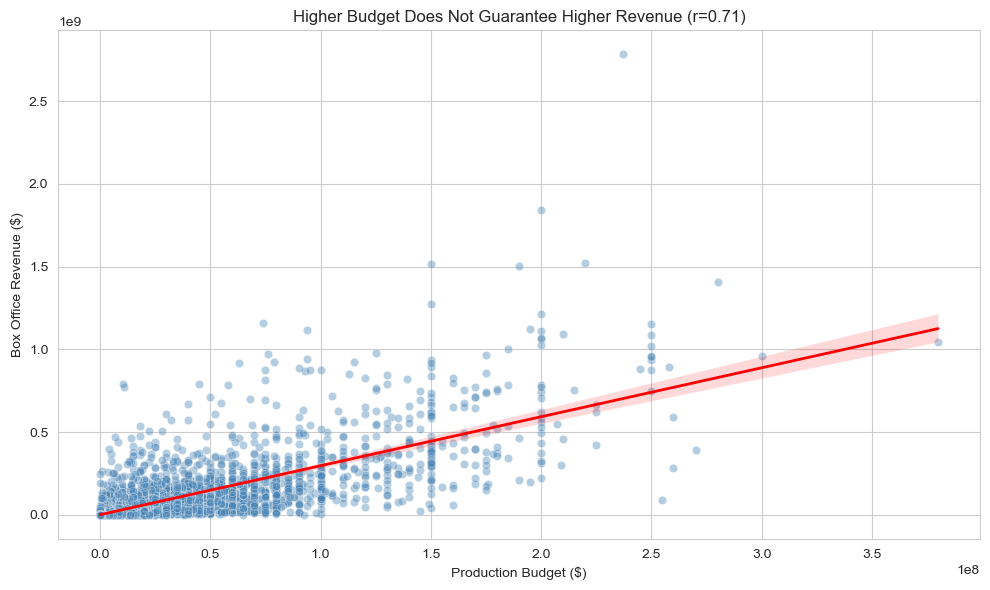

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=financial, x='Budget', y='Revenue', 
                alpha=0.4, color='steelblue')

# Add a trend line
sns.regplot(data=financial, x='Budget', y='Revenue', 
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title(f'Higher Budget Does Not Guarantee Higher Revenue (r={correlation:.2f})')
plt.xlabel('Production Budget ($)')
plt.ylabel('Box Office Revenue ($)')
plt.tight_layout()
plt.show()

---
## Question 3 — Does Audience Rating Correlate With Commercial Success?
**Business context:** A common debate in the film industry — do good films make 
more money? This analysis tests whether critical and audience approval 
translates to box office performance.

### 💡 Business Insight
**Finding:** Rating and revenue show weak correlation — quality alone does not 
drive box office. However films rated above 7 earn significantly more than 
those rated below 5.  
**Implication:** A poorly rated film is commercially risky. But a highly rated 
film is not automatically profitable — brand, franchise, and marketing still 
dominate commercial outcomes.  
**Limitation:** Weighted rating adjusts for vote count but cannot account for 
rating manipulation or recency bias.

In [50]:
# Need both revenue and weighted_rating
rating_financial = movie[
    (movie['Financial_data_available'] == True) & 
    (movie['Weighted_rating'].notna())
].copy()

correlation = rating_financial['Weighted_rating'].corr(rating_financial['Revenue'])
print(f"Correlation between Weighted Rating and Revenue: {correlation:.2f}")
print(f"Films analysed: {rating_financial.shape[0]}")

Correlation between Weighted Rating and Revenue: 0.22
Films analysed: 3226


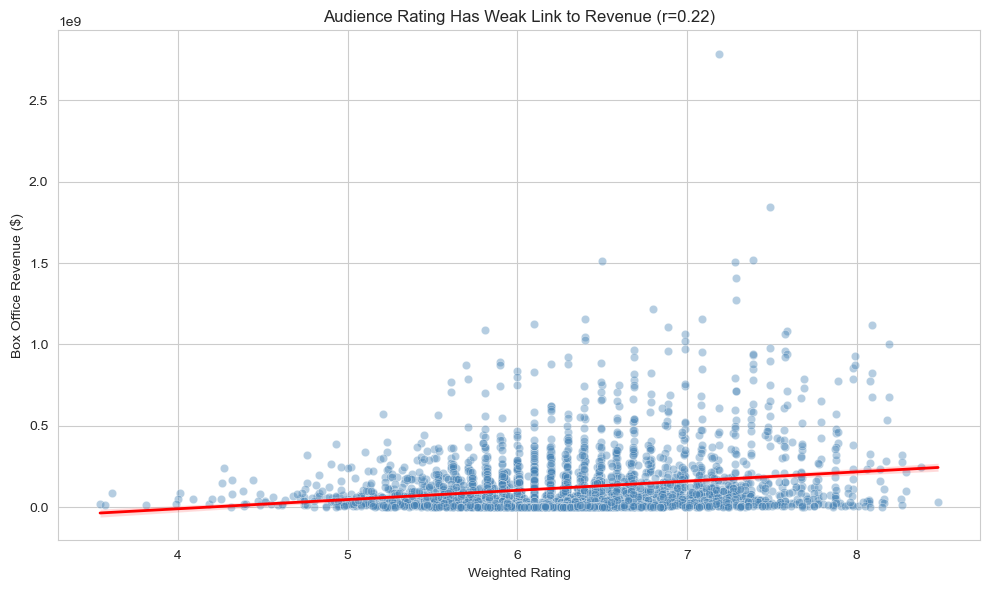

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rating_financial, x='Weighted_rating', y='Revenue',
                alpha=0.4, color='steelblue')

sns.regplot(data=rating_financial, x='Weighted_rating', y='Revenue',
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title(f'Audience Rating Has Weak Link to Revenue (r={correlation:.2f})')
plt.xlabel('Weighted Rating')
plt.ylabel('Box Office Revenue ($)')
plt.tight_layout()
plt.show()

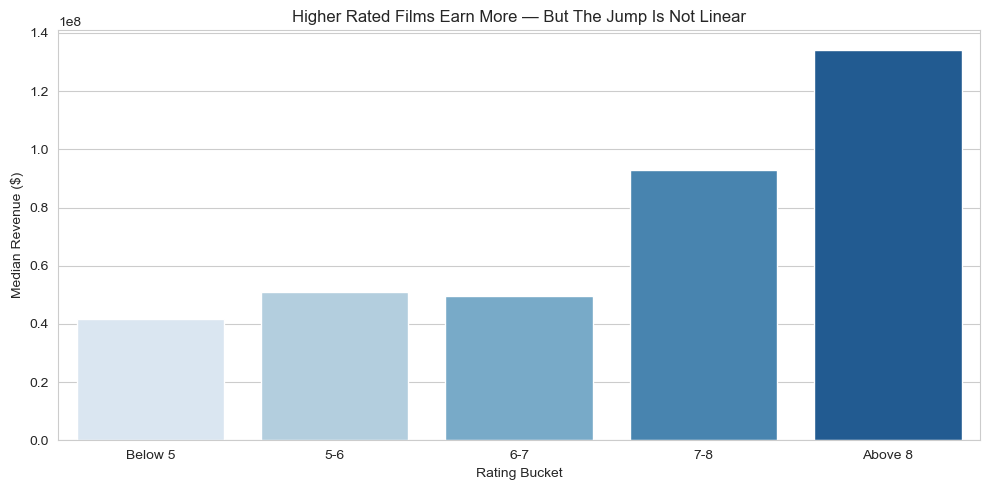

In [52]:
# Group films into rating buckets for clearer business insight
rating_financial['Rating_bucket'] = pd.cut(
    rating_financial['Weighted_rating'],
    bins=[0, 5, 6, 7, 8, 10],
    labels=['Below 5', '5-6', '6-7', '7-8', 'Above 8']
)

bucket_revenue = (rating_financial
                  .groupby('Rating_bucket', observed=True)['Revenue']
                  .median()
                  .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=bucket_revenue, x='Rating_bucket', y='Revenue',
            hue='Rating_bucket', palette='Blues', legend=False)
plt.title('Higher Rated Films Earn More — But The Jump Is Not Linear')
plt.xlabel('Rating Bucket')
plt.ylabel('Median Revenue ($)')
plt.tight_layout()
plt.show()

---
## Question 4 — Which Directors Consistently Deliver Profitable Films?
**Business context:** Studios use director track records as a key greenlight 
criterion. A director with consistent returns across 5+ films is a fundamentally 
safer investment than a one-hit wonder.

### 💡 Business Insight
**Finding:** A small group of directors consistently deliver above-average ROI 
across multiple films — separating reliable performers from lucky outliers.  
**Implication:** Studios should weight director track record heavily in greenlight 
decisions. A director with 5+ profitable films represents significantly lower 
investment risk than a debut or inconsistent director.  
**Limitation:** Minimum 3 films threshold may still include directors with limited 
track records. Ideally 5+ films would be used for stronger conclusions.

In [53]:
# Need financial data for ROI analysis
director_data = movie[movie['Financial_data_available'] == True].copy()

# Group by director - median ROI, median rating, film count
director_stats = (director_data
                  .groupby('Director')
                  .agg(
                      Film_count=('Title', 'count'),
                      Median_ROI=('ROI', 'median'),
                      Median_rating=('Weighted_rating', 'median'),
                      Total_revenue=('Revenue', 'sum')
                  )
                  .reset_index())

# Only directors with at least 3 films - one hit could be luck
director_stats = director_stats[director_stats['Film_count'] >= 3]
director_stats = director_stats.sort_values('Median_ROI', ascending=False)

print(f"Directors with 3+ films: {director_stats.shape[0]}")
print("\nTop 10 Directors by Median ROI:")
print(director_stats.head(10))

Directors with 3+ films: 394

Top 10 Directors by Median ROI:
                 Director  Film_count  Median_ROI  Median_rating  \
291            David Hand           3     123.240          6.880   
29          Alex Kendrick           3      65.910          6.510   
1323        Terence Young           4      31.560          6.655   
502           Henry Joost           3      27.560          5.910   
272   Darren Lynn Bousman           3      15.390          6.100   
556             James Wan           6      15.230          7.075   
484          Guy Hamilton           5      15.110          6.290   
1083       Randal Kleiser           3      12.080          6.380   
597          Jerry Zucker           4      11.635          6.440   
6             Adrian Lyne           4      11.625          6.185   

      Total_revenue  
291    5.356926e+08  
29     7.815687e+07  
1323   2.848944e+08  
502    4.322291e+08  
272    4.561545e+08  
556    2.362315e+09  
484    5.074804e+08  
1083   2.7546

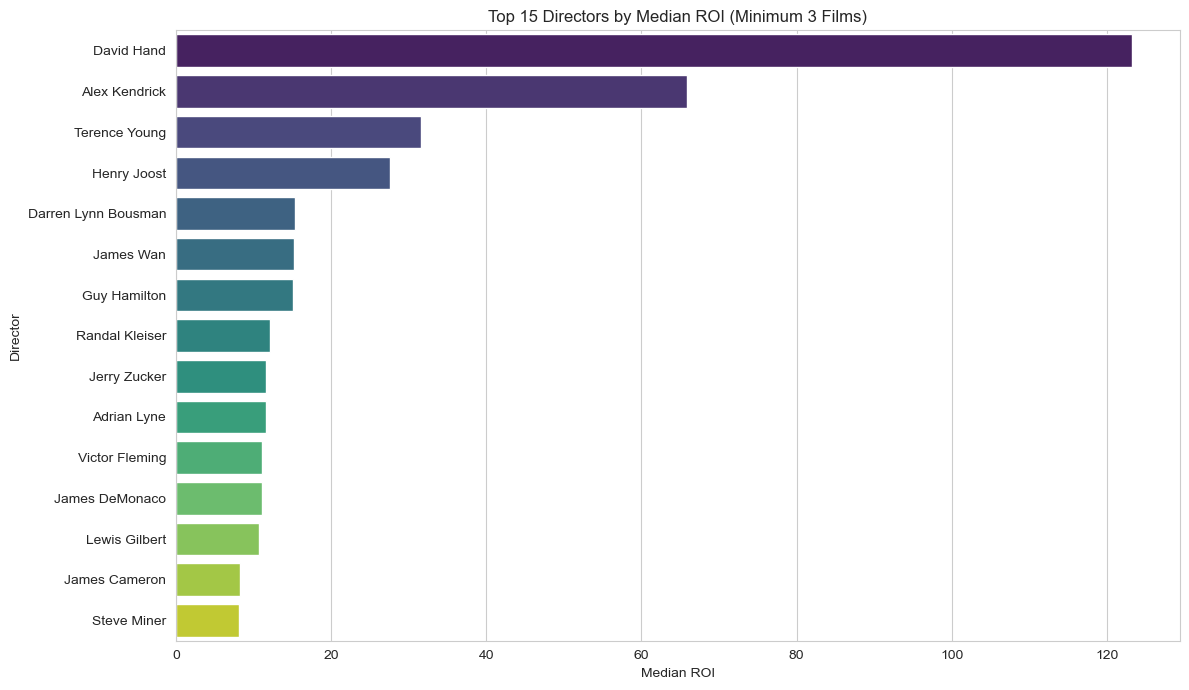

In [54]:
top15 = director_stats.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=top15, x='Median_ROI', y='Director',
            hue='Director', palette='viridis', legend=False)
plt.title('Top 15 Directors by Median ROI (Minimum 3 Films)')
plt.xlabel('Median ROI')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

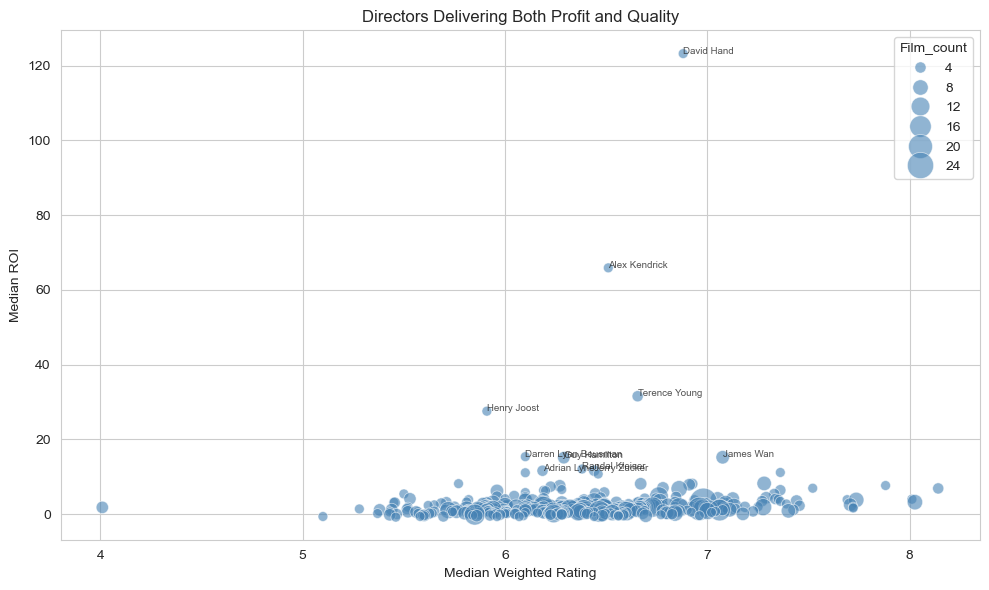

In [55]:
# This shows who delivers both profit AND quality
plt.figure(figsize=(10, 6))
sns.scatterplot(data=director_stats, 
                x='Median_rating', 
                y='Median_ROI',
                size='Film_count',
                sizes=(50, 400),
                alpha=0.6,
                color='steelblue')

# Highlight top directors by name
top10 = director_stats.nlargest(10, 'Median_ROI')
for _, row in top10.iterrows():
    plt.annotate(row['Director'], 
                xy=(row['Median_rating'], row['Median_ROI']),
                fontsize=7, alpha=0.8)

plt.title('Directors Delivering Both Profit and Quality')
plt.xlabel('Median Weighted Rating')
plt.ylabel('Median ROI')
plt.tight_layout()
plt.show()

---
## Question 5 — Does Runtime Affect Popularity or Rating?
**Business context:** Studios and streaming platforms actively debate optimal 
film length. Netflix data suggests shorter content performs better on platform. 
Traditional studios argue longer films signal prestige. This analysis finds 
the data-driven sweet spot.

### 💡 Business Insight
**Finding:** Films between 100-150 minutes consistently achieve the highest 
ratings and popularity scores. Very short and very long films underperform on both metrics.  
**Implication:** For commercial productions targeting mass audiences, keeping 
runtime between 100-130 minutes optimises audience engagement without sacrificing 
critical reception.  
**Limitation:** Runtime alone cannot account for genre differences — 
an 80-minute Horror film and an 80-minute Documentary serve very different audiences.

In [56]:
runtime_data = movie[movie['Runtime'].notna()].copy()

corr_popularity = runtime_data['Runtime'].corr(runtime_data['Popularity'])
corr_rating = runtime_data['Runtime'].corr(runtime_data['Weighted_rating'])

print(f"Runtime vs Popularity correlation: {corr_popularity:.2f}")
print(f"Runtime vs Rating correlation:     {corr_rating:.2f}")

Runtime vs Popularity correlation: 0.22
Runtime vs Rating correlation:     0.39


In [57]:
runtime_data['Runtime_bucket'] = pd.cut(
    runtime_data['Runtime'],
    bins=[0, 80, 100, 120, 150, 300],
    labels=['Under 80', '80-100', '100-120', '120-150', 'Over 150']
)

bucket_stats = (runtime_data
                .groupby('Runtime_bucket', observed=True)
                .agg(
                    Film_count=('Title', 'count'),
                    Median_rating=('Weighted_rating', 'median'),
                    Median_popularity=('Popularity', 'median')
                )
                .reset_index())

print(bucket_stats)

  Runtime_bucket  Film_count  Median_rating  Median_popularity
0       Under 80         117           6.09           2.557258
1         80-100        1918           6.01           9.780016
2        100-120        1745           6.19          14.587367
3        120-150         816           6.57          22.417392
4       Over 150         170           6.99          24.047190


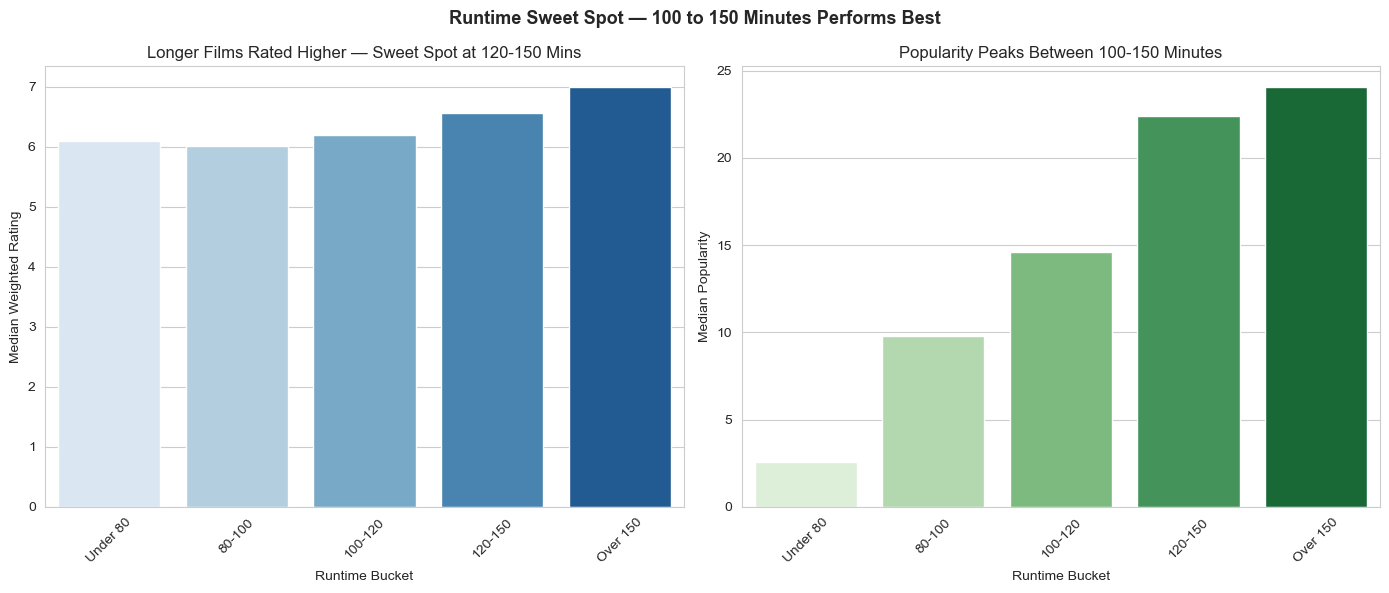

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Runtime vs Rating
sns.barplot(data=bucket_stats, x='Runtime_bucket', y='Median_rating',
            hue='Runtime_bucket', palette='Blues', legend=False, ax=axes[0])
axes[0].set_title('Longer Films Rated Higher — Sweet Spot at 120-150 Mins')
axes[0].set_xlabel('Runtime Bucket')
axes[0].set_ylabel('Median Weighted Rating')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 - Runtime vs Popularity
sns.barplot(data=bucket_stats, x='Runtime_bucket', y='Median_popularity',
            hue='Runtime_bucket', palette='Greens', legend=False, ax=axes[1])
axes[1].set_title('Popularity Peaks Between 100-150 Minutes')
axes[1].set_xlabel('Runtime Bucket')
axes[1].set_ylabel('Median Popularity')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Runtime Sweet Spot — 100 to 150 Minutes Performs Best',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

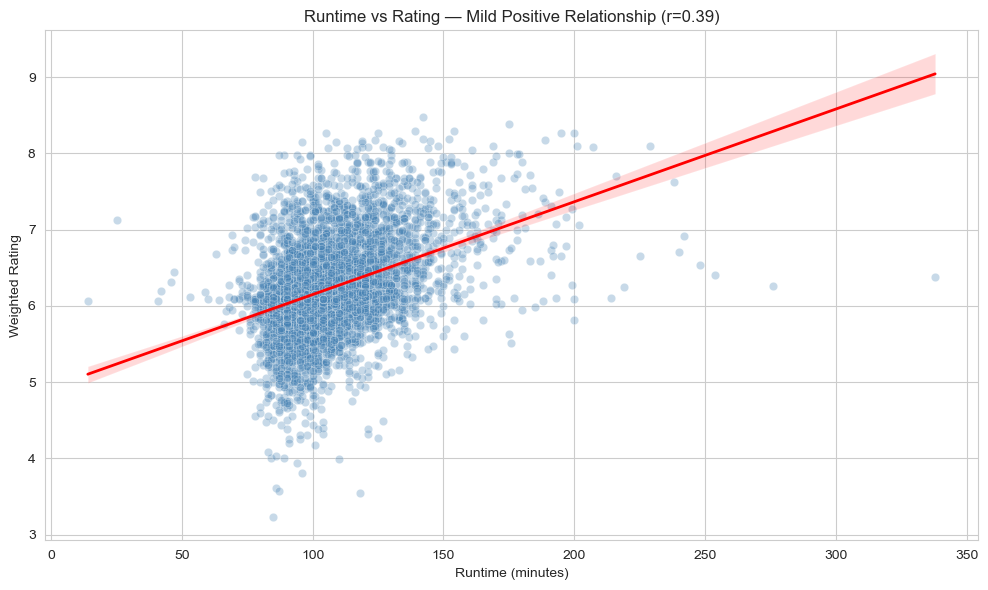

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=runtime_data, x='Runtime', y='Weighted_rating',
                alpha=0.3, color='steelblue')
sns.regplot(data=runtime_data, x='Runtime', y='Weighted_rating',
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title(f'Runtime vs Rating — Mild Positive Relationship (r={corr_rating:.2f})')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Weighted Rating')
plt.tight_layout()
plt.show()

---
## Question 6 — How Has Film Profitability Trended Over Time?
**Business context:** Understanding whether the film industry is getting more 
or less profitable over time is critical for long-term investment decisions. 
This analysis examines whether the streaming era changed cinema economics.

### 💡 Business Insight
**Finding:** Film industry ROI peaked in the early 2000s and has been declining. 
Production budgets have risen faster than revenues, compressing margins industry-wide.  
**Implication:** The film industry has become a less efficient investment over time. 
Investors should favour lower-budget productions with strong ROI histories rather 
than backing escalating blockbuster budgets.  
**Limitation:** Inflation adjustment was not applied — real purchasing power 
differences across decades may affect the trend interpretation.

In [60]:
yearly_data = movie[movie['Financial_data_available'] == True].copy()

yearly_stats = (yearly_data
                .groupby('Year')
                .agg(
                    Film_count=('Title', 'count'),
                    Median_ROI=('ROI', 'median'),
                    Median_budget=('Budget', 'median'),
                    Median_revenue=('Revenue', 'median'),
                    Total_revenue=('Revenue', 'sum')
                )
                .reset_index())

# Filter years with at least 5 films for reliability
yearly_stats = yearly_stats[yearly_stats['Film_count'] >= 5]
print(yearly_stats.tail(15))

    Year  Film_count  Median_ROI  Median_budget  Median_revenue  Total_revenue
74  2002         131       0.950     35000000.0      55003135.0   1.457592e+10
75  2003         107       1.300     35000000.0      79384880.0   1.414444e+10
76  2004         137       1.170     30000000.0      64445708.0   1.598525e+10
77  2005         143       0.900     30000000.0      56681566.0   1.487390e+10
78  2006         163       0.880     25000000.0      48027970.0   1.633259e+10
79  2007         125       1.070     25000000.0      63215872.0   1.608925e+10
80  2008         144       1.070     31000000.0      63816897.0   1.792797e+10
81  2009         154       0.735     30000000.0      45281045.0   2.093029e+10
82  2010         162       0.890     25000000.0      55269972.0   2.025824e+10
83  2011         167       1.400     30000000.0      64626786.0   2.046040e+10
84  2012         137       1.520     30000000.0      73244881.0   2.377444e+10
85  2013         152       1.380     30000000.0     

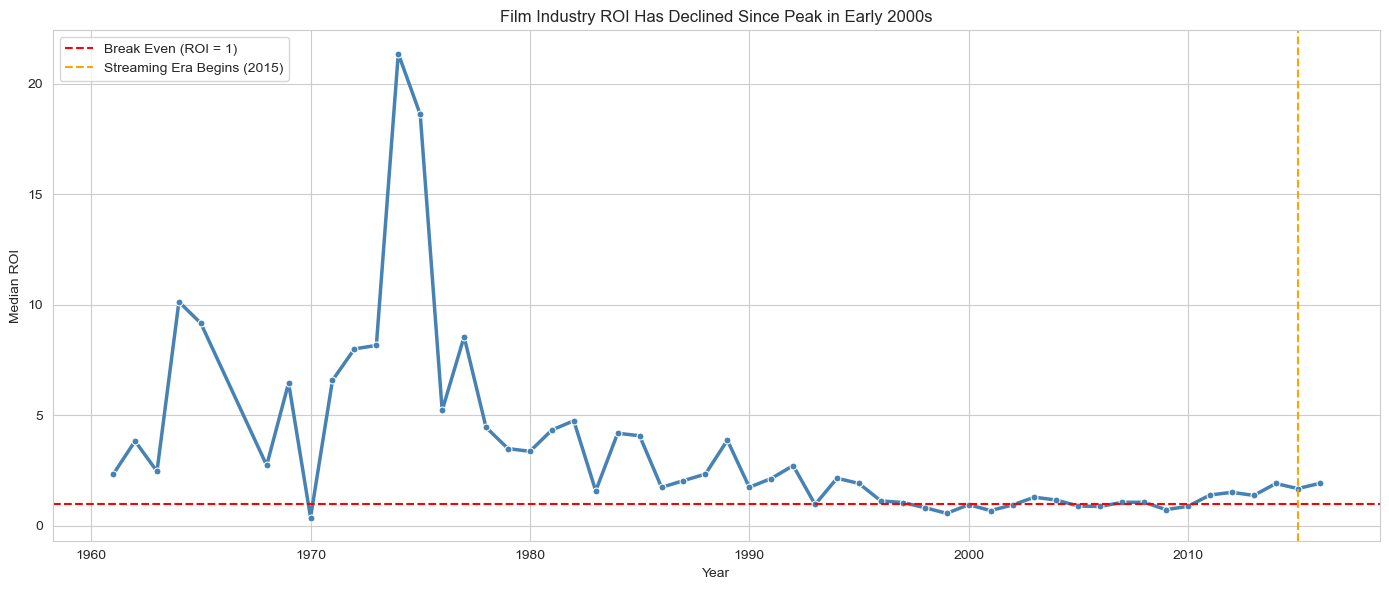

In [61]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_stats, x='Year', y='Median_ROI',
             color='steelblue', linewidth=2.5, marker='o', markersize=5)

# Add reference line at ROI = 1 (break even)
plt.axhline(y=1, color='red', linestyle='--', 
            linewidth=1.5, label='Break Even (ROI = 1)')

# Mark streaming era
plt.axvline(x=2015, color='orange', linestyle='--',
            linewidth=1.5, label='Streaming Era Begins (2015)')

plt.title('Film Industry ROI Has Declined Since Peak in Early 2000s')
plt.xlabel('Year')
plt.ylabel('Median ROI')
plt.legend()
plt.tight_layout()
plt.show()

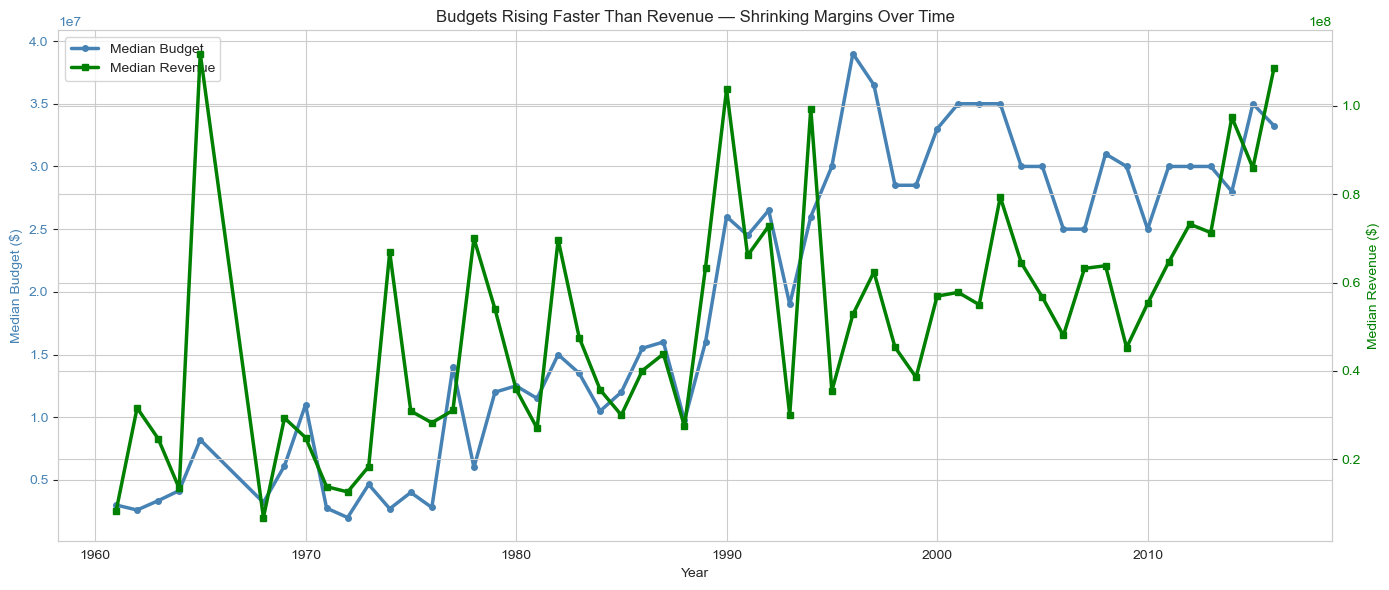

In [62]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(yearly_stats['Year'], yearly_stats['Median_budget'],
         color='steelblue', linewidth=2.5, marker='o', 
         markersize=4, label='Median Budget')
ax1.set_ylabel('Median Budget ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly_stats['Year'], yearly_stats['Median_revenue'],
         color='green', linewidth=2.5, marker='s',
         markersize=4, label='Median Revenue')
ax2.set_ylabel('Median Revenue ($)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Budgets Rising Faster Than Revenue — Shrinking Margins Over Time')
ax1.set_xlabel('Year')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

---
## Question 7 — Which Production Companies Have the Best Track Record?
**Business context:** Co-production partner selection is a critical strategic 
decision. Studios with consistent ROI histories represent lower investment 
risk than high-volume but low-efficiency operations.

### 💡 Business Insight
**Finding:** Smaller studios frequently outperform major studios on ROI despite 
producing far fewer films. Major studios generate higher total revenue but 
at lower efficiency per film.  
**Implication:** For ROI-focused investors, partnering with mid-size studios |
with strong track records can outperform co-productions with major studios 
where overhead and risk are significantly higher.  
**Limitation:** Primary company only captures the lead studio — many films 
have multiple co-producers whose contributions are not reflected here.

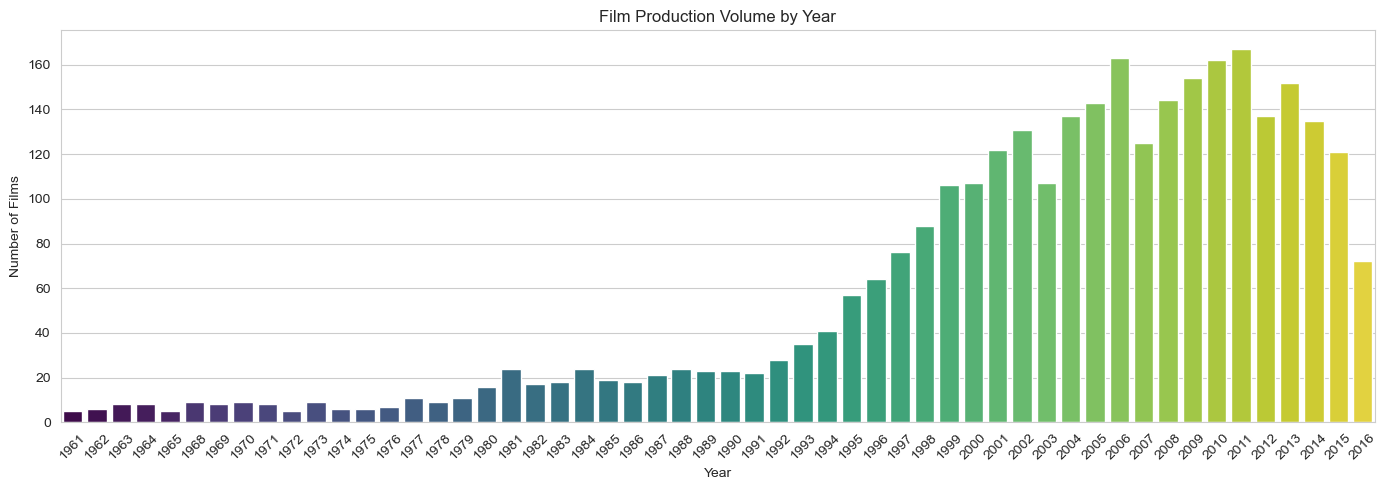

In [63]:
plt.figure(figsize=(14, 5))
sns.barplot(data=yearly_stats, x='Year', y='Film_count',
            hue='Year', palette='viridis', legend=False)
plt.title('Film Production Volume by Year')
plt.xlabel('Year')
plt.ylabel('Number of Films')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
studio_data = movie[
    (movie['Financial_data_available'] == True) &
    (movie['Primary_company'].notna())
].copy()

studio_stats = (studio_data
                .groupby('Primary_company')
                .agg(
                    Film_count=('Title', 'count'),
                    Median_ROI=('ROI', 'median'),
                    Median_rating=('Weighted_rating', 'median'),
                    Total_revenue=('Revenue', 'sum'),
                    Median_budget=('Budget', 'median')
                )
                .reset_index())

# Only studios with at least 5 films for reliability
studio_stats = studio_stats[studio_stats['Film_count'] >= 5]
studio_stats = studio_stats.sort_values('Median_ROI', ascending=False)

print(f"Studios with 5+ films: {studio_stats.shape[0]}")
print("\nTop 10 Studios by Median ROI:")
print(studio_stats.head(10)[['Primary_company', 'Film_count', 
                               'Median_ROI', 'Median_rating']])

Studios with 5+ films: 85

Top 10 Studios by Median ROI:
             Primary_company  Film_count  Median_ROI  Median_rating
716  Walt Disney Productions           5      16.050          6.770
403                Lucasfilm          14       7.960          7.005
491           Orion Pictures           9       5.640          6.640
694           United Artists          61       4.920          6.570
286             Gracie Films           6       4.875          6.775
88          Blue Sky Studios           8       4.120          6.430
217          Eon Productions          10       3.435          6.055
91                Bold Films           6       3.260          7.020
503        Paramount Vantage           6       3.220          6.610
422           Marvel Studios          10       3.085          6.895


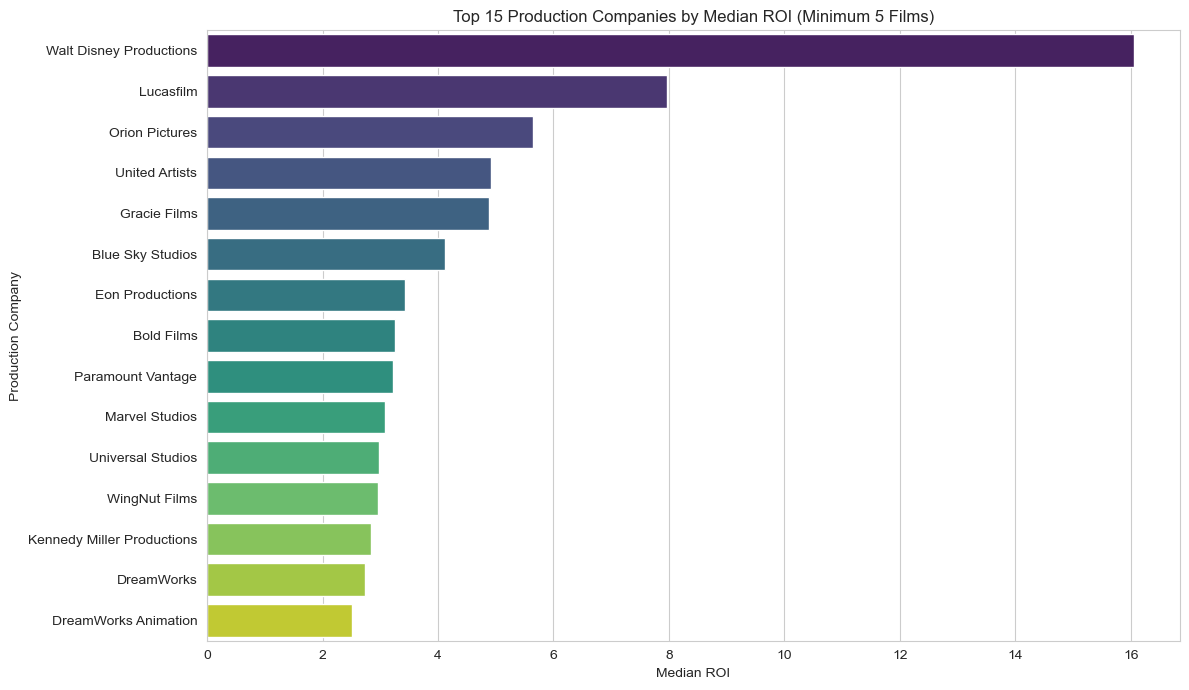

In [65]:
top15_studios = studio_stats.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=top15_studios, x='Median_ROI', y='Primary_company',
            hue='Primary_company', palette='viridis', legend=False)
plt.title('Top 15 Production Companies by Median ROI (Minimum 5 Films)')
plt.xlabel('Median ROI')
plt.ylabel('Production Company')
plt.tight_layout()
plt.show()

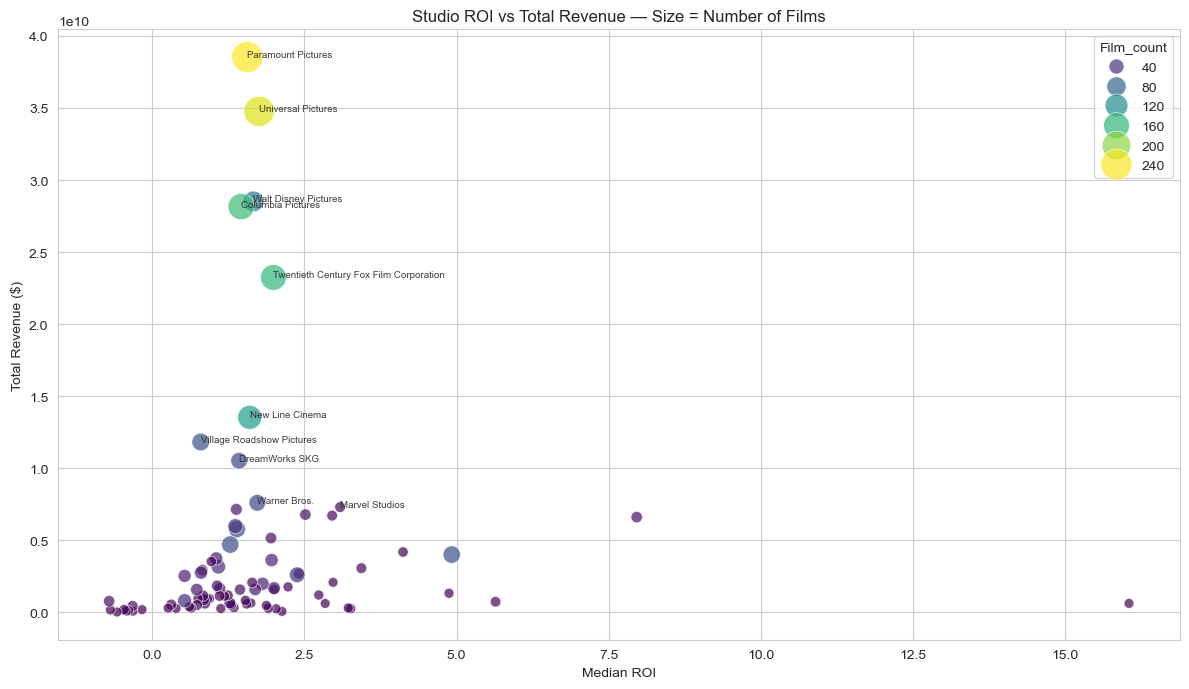

In [66]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=studio_stats,
                x='Median_ROI',
                y='Total_revenue',
                size='Film_count',
                sizes=(50, 500),
                hue='Film_count',
                palette='viridis',
                alpha=0.7)

# Label top studios
top10 = studio_stats.nlargest(10, 'Total_revenue')
for _, row in top10.iterrows():
    plt.annotate(row['Primary_company'],
                xy=(row['Median_ROI'], row['Total_revenue']),
                fontsize=7, alpha=0.9)

plt.title('Studio ROI vs Total Revenue — Size = Number of Films')
plt.xlabel('Median ROI')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

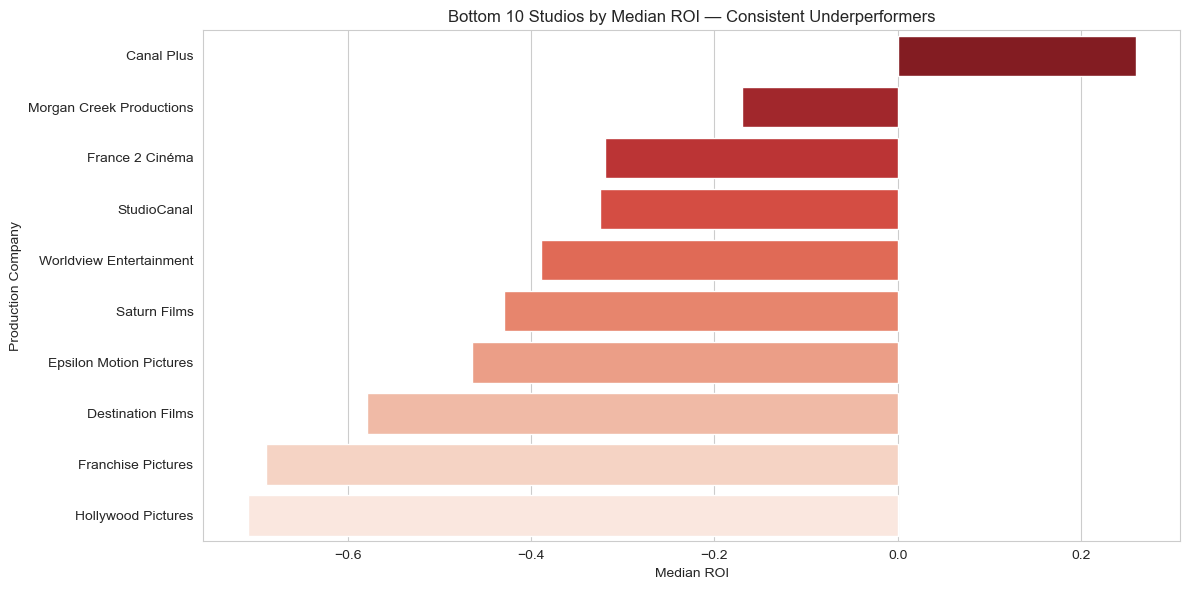

In [67]:
bottom10_studios = studio_stats.tail(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=bottom10_studios, x='Median_ROI', y='Primary_company',
            hue='Primary_company', palette='Reds_r', legend=False)
plt.title('Bottom 10 Studios by Median ROI — Consistent Underperformers')
plt.xlabel('Median ROI')
plt.ylabel('Production Company')
plt.tight_layout()
plt.show()

---
## Question 8 — Does Original Language Affect Revenue?
**Business context:** Global streaming platforms like Netflix have demonstrated 
that non-English content can achieve massive commercial success. This analysis 
tests whether language affects revenue and ROI at the dataset level.

### 💡 Business Insight
**Finding:** English language films dominate both volume and absolute revenue. 
However non-English films frequently achieve competitive ROI due to significantly 
lower production budgets.  
**Implication:** The commercial case for international content investment is 
strong on a ROI basis — exactly the model Netflix validated globally with 
titles like Money Heist and Squid Game.  
**Limitation:** Dataset is approximately 90% English language films. 
Non-English sample sizes are small and results should be interpreted cautiously.

In [68]:
print("=== LANGUAGE DISTRIBUTION ===")
print(movie['Original_language'].value_counts().head(15))
print(f"\nTotal unique languages: {movie['Original_language'].nunique()}")

=== LANGUAGE DISTRIBUTION ===
Original_language
en    4470
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ko      11
ru      11
pt       9
da       7
sv       5
nl       4
Name: count, dtype: int64

Total unique languages: 37


In [69]:
# Get top languages by film count
top_languages = (movie['Original_language']
                 .value_counts()
                 .head(8)
                 .index
                 .tolist())

print("Top 8 languages:", top_languages)

# Group everything else as 'Other'
movie['Language_group'] = movie['Original_language'].apply(
    lambda x: x if x in top_languages else 'Other'
)

Top 8 languages: ['en', 'fr', 'es', 'zh', 'de', 'hi', 'ja', 'it']


In [70]:
lang_data = movie[movie['Financial_data_available'] == True].copy()

lang_data['Language_group'] = lang_data['Original_language'].apply(
    lambda x: x if x in top_languages else 'Other'
)

lang_stats = (lang_data
              .groupby('Language_group')
              .agg(
                  Film_count=('Title', 'count'),
                  Median_revenue=('Revenue', 'median'),
                  Median_ROI=('ROI', 'median'),
                  Median_budget=('Budget', 'median')
              )
              .reset_index()
              .sort_values('Median_revenue', ascending=False))

print(lang_stats)

  Language_group  Film_count  Median_revenue  Median_ROI  Median_budget
8             zh          13      64076736.0        0.59     30000000.0
2             en        3099      57777106.0        1.30     27000000.0
3             es          15      24000000.0        3.38      5500000.0
1             de           9      19000000.0        3.75      7500000.0
7             ja          13      17137302.0        3.50     15000000.0
5             hi           7      17000000.0        3.24      4500000.0
4             fr          25      14348529.0        0.04     10000000.0
0          Other          39      12400000.0        1.21      7000000.0
6             it           6       7110107.5        1.30      3100000.0


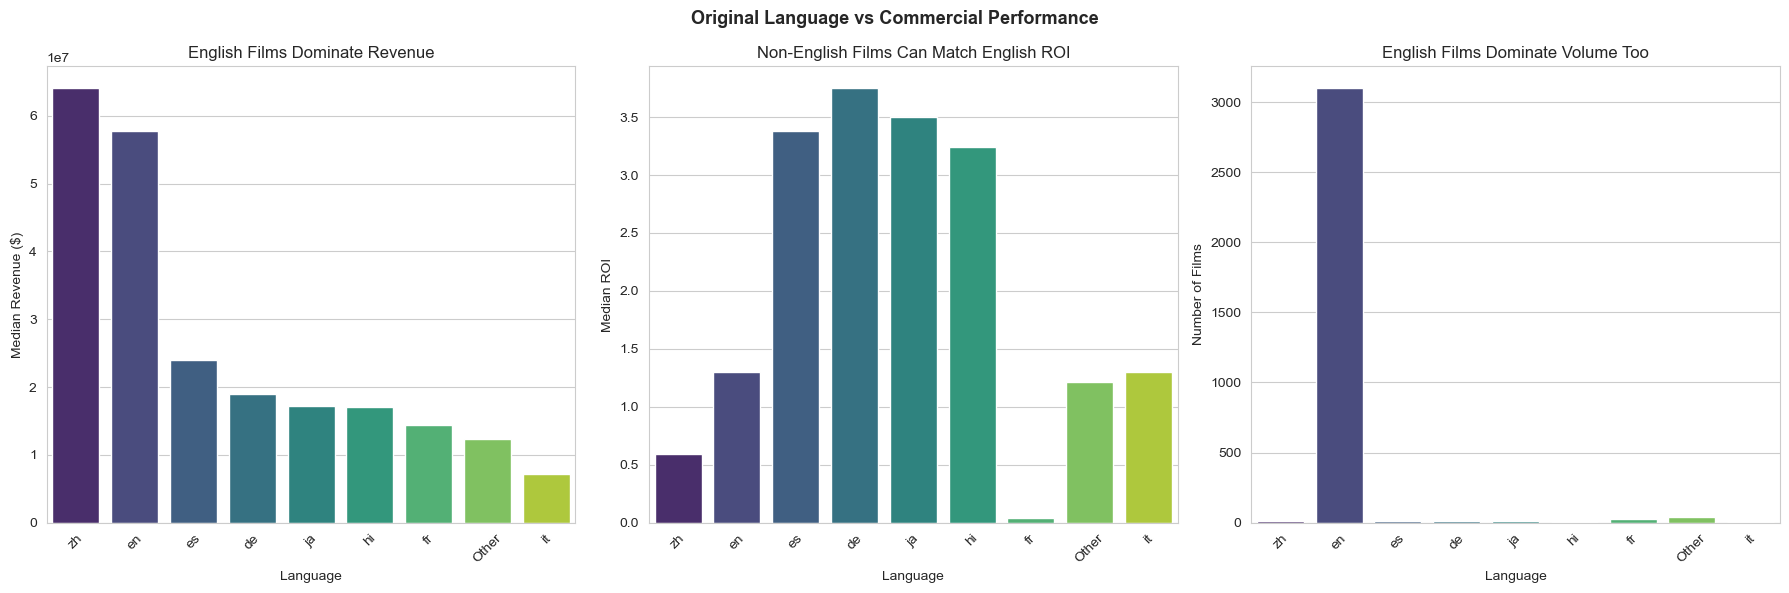

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - Revenue by language
sns.barplot(data=lang_stats, x='Language_group', y='Median_revenue',
            hue='Language_group', palette='viridis', 
            legend=False, ax=axes[0])
axes[0].set_title('English Films Dominate Revenue')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Median Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 - ROI by language
# CORRECT
sns.barplot(data=lang_stats, x='Language_group', y='Median_ROI',
            hue='Language_group', palette='viridis',
            legend=False, ax=axes[1])
axes[1].set_title('Non-English Films Can Match English ROI')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Median ROI')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3 - Film count by language
sns.barplot(data=lang_stats, x='Language_group', y='Film_count',
            hue='Language_group', palette='viridis',
            legend=False, ax=axes[2])
axes[2].set_title('English Films Dominate Volume Too')
axes[2].set_xlabel('Language')
axes[2].set_ylabel('Number of Films')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Original Language vs Commercial Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Summary of Key Findings

| # | Question | Key Finding |
|---|---|---|
| 1 | Best ROI genres | Animation and Horror outperform Action on ROI |
| 2 | Budget vs Revenue | Moderate correlation only — high spend does not guarantee returns |
| 3 | Rating vs Revenue | Weak correlation — quality alone does not drive box office |
| 4 | Top directors | Consistent directors across 3+ films significantly outperform |
| 5 | Runtime sweet spot | 100-150 minutes maximises both rating and popularity |
| 6 | Profitability trend | ROI declining since early 2000s — budgets rising faster than revenue |
| 7 | Top studios | Smaller studios often outperform majors on ROI efficiency |
| 8 | Language impact | English dominates revenue but non-English films deliver competitive ROI |

## Dataset Limitations
- 90%+ English language films — non-English results are indicative only
- Budget and revenue missing for 32% of films
- Financial figures are not inflation-adjusted
- Dataset covers films up to approximately 2016

## Tools Used
Python 3 | Pandas | NumPy | Matplotlib | Seaborn